# ML量化框架使用示例

本Notebook展示如何使用可插拔的机器学习模型进行量化交易策略开发。

## 1. 导入必要的模块

In [1]:
import sys
import os
from pathlib import Path

# 将项目根目录添加到路径
PROJECT_ROOT = Path(os.getcwd()).parent if 'quant-learning' in str(Path.cwd()) else Path(os.getcwd())
sys.path.insert(0, str(PROJECT_ROOT))

print(f'Python 路径: {sys.path[0]}')

# 数据加载与特征工程
from data_loader import StockDataLoader, time_series_split
from feature_engineering import FeatureEngineer
from config import DATA_PATH
from models.sklearn_models import (
    RidgeRegressionModel, RandomForestModel, XGBoostModel, LightGBMModel
)
from models.pytorch_models import MLPModel, LSTMModel

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print('✅ 所有模块导入成功！')
print(f'数据路径: {DATA_PATH}')


Python 路径: /Users/harry
✅ 所有模块导入成功！
数据路径: /Users/harry/quant-learning/data/a_stock_history_price.csv


## 2. 数据加载

In [2]:
# 加载数据
# 手动指定数据路径（如果环境变量未设置）
data_path = Path('/Users/harry/quant-learning/data/a_stock_history_price.csv')
if not data_path.exists():
    data_path = Path('/Users/harry/quant-learning/data/a_stock_history_price_20260223_副本.csv')

loader = StockDataLoader(data_path)
df = loader.load(years_back=5)

# 选择1000只样本股票
# selected_codes = loader.select_sample_codes(n=100)
# df = df[df['code'].isin(selected_codes)]

print(f'📊 最终数据集: {len(df):,} 条记录, {df["code"].nunique()} 只股票')
print(f'日期范围: {df["date"].min().date()} ~ {df["date"].max().date()}')

📂 加载数据: /Users/harry/quant-learning/data/a_stock_history_price.csv
   原始: 7,783,131 行
   加载后: 6,706,561 行 | 6403 只股票
📊 最终数据集: 6,706,561 条记录, 6403 只股票
日期范围: 2021-02-18 ~ 2026-02-13


## 3. 数据集划分（时序划分）

In [3]:
train_df, val_df, test_df = time_series_split(df)

print(f"训练集: {len(train_df)} 行")
print(f"验证集: {len(val_df)} 行")
print(f"测试集: {len(test_df)} 行")


⏰ 时间序列数据集划分...
   训练集: 3,755,139 (2021-02-18 ~ 2024-02-19)
   验证集: 1,433,282 (2024-02-20 ~ 2025-02-20)
   测试集: 1,518,140 (2025-02-21 ~ 2026-02-13)
训练集: 3755139 行
验证集: 1433282 行
测试集: 1518140 行


In [4]:
# 验证时序划分正确性（防止数据泄露）
print('\n' + '='*60)
print('🔒 时序划分验证 - 确保无数据穿越')
print('='*60)

# 获取各数据集的时间范围
train_start, train_end = train_df['date'].min(), train_df['date'].max()
val_start, val_end = val_df['date'].min(), val_df['date'].max()
test_start, test_end = test_df['date'].min(), test_df['date'].max()

print('📅 时间范围:')
print(f"  训练集: {train_start.date()} ~ {train_end.date()}")
print(f"  验证集: {val_start.date()} ~ {val_end.date()}")
print(f"  测试集: {test_start.date()} ~ {test_end.date()}")

# 验证无时间重叠
assert train_end < val_start, '❌ 训练集和验证集有重叠!'
assert val_end < test_start, '❌ 验证集和测试集有重叠!'

# 验证时间间隙
train_val_gap = (val_start - train_end).days
val_test_gap = (test_start - val_end).days

print(f"\n✅ 无时间穿越风险!")
print(f"  训练-验证间隔: {train_val_gap} 天")
print(f"  验证-测试间隔: {val_test_gap} 天")

# 验证测试集完全隐藏
print('\n🔐 测试集隐藏验证:')
train_val_codes = set(train_df['code'].unique()) | set(val_df['code'].unique())
test_codes = set(test_df['code'].unique())

print(f"  训练+验证股票数: {len(train_val_codes)}")
print(f"  测试集股票数: {len(test_codes)}")
print(f"  共同股票: {len(train_val_codes & test_codes)} (允许有重复股票，但时间不能重叠)")

print('\n✅ 验证通过! 可以安全地进行模型训练')


🔒 时序划分验证 - 确保无数据穿越
📅 时间范围:
  训练集: 2021-02-18 ~ 2024-02-19
  验证集: 2024-02-20 ~ 2025-02-20
  测试集: 2025-02-21 ~ 2026-02-13

✅ 无时间穿越风险!
  训练-验证间隔: 1 天
  验证-测试间隔: 1 天

🔐 测试集隐藏验证:
  训练+验证股票数: 6040
  测试集股票数: 6403
  共同股票: 6040 (允许有重复股票，但时间不能重叠)

✅ 验证通过! 可以安全地进行模型训练


## 4. 特征工程

In [5]:
from sklearn.preprocessing import StandardScaler

# 重要: 测试集必须在整个训练过程中保持隐藏!
# 所有特征计算和标准化参数只能从训练集学习

fe = FeatureEngineer()

print("\n🔧 步骤1: 只在训练集上计算特征（验证集和测试集不可见）")
train_features = fe.create_features(train_df, pred_horizon=5)
print(f"   训练集特征计算完成: {len(train_features)} 条")

print("\n🔧 步骤2: 使用训练集的统计量处理验证集")
val_features = fe.create_features(val_df, pred_horizon=5)
print(f"   验证集特征计算完成: {len(val_features)} 条")

print("\n🔧 步骤3: 使用训练集的统计量处理测试集（模拟真实场景）")
test_features = fe.create_features(test_df, pred_horizon=5)
print(f"   测试集特征计算完成: {len(test_features)} 条")

print("\n📊 步骤4: 标准化（仅在训练集上 fit，验证/测试集只 transform）")
scaler = StandardScaler()

# 只在训练集上 fit_scaler=True，其他为 False
X_train, y_train, _ = fe.prepare_xy(train_features, scaler, fit_scaler=True)
X_val, y_val, _ = fe.prepare_xy(val_features, scaler, fit_scaler=False)
X_test, y_test, _ = fe.prepare_xy(test_features, scaler, fit_scaler=False)

print(f"\n✅ 数据准备完成:")
print(f"   训练集: X{X_train.shape}, y{y_train.shape}")
print(f"   验证集: X{X_val.shape}, y{y_val.shape}")
print(f"   测试集: X{X_test.shape}, y{y_test.shape} (严格隐藏)")

# 从 fe 对象获取特征列
feature_cols = fe.feature_cols
print(f"\n📋 特征数量: {len(feature_cols)}")
print(f"   示例: {feature_cols} ")


🔧 步骤1: 只在训练集上计算特征（验证集和测试集不可见）

🔧 构建特征...
   特征数: 40
   有效样本: 3,353,857
   训练集特征计算完成: 3353857 条

🔧 步骤2: 使用训练集的统计量处理验证集

🔧 构建特征...
   特征数: 40
   有效样本: 1,018,926
   验证集特征计算完成: 1018926 条

🔧 步骤3: 使用训练集的统计量处理测试集（模拟真实场景）

🔧 构建特征...
   特征数: 40
   有效样本: 1,075,958
   测试集特征计算完成: 1075958 条

📊 步骤4: 标准化（仅在训练集上 fit，验证/测试集只 transform）

✅ 数据准备完成:
   训练集: X(3353857, 40), y(3353857,)
   验证集: X(1018926, 40), y(1018926,)
   测试集: X(1075958, 40), y(1075958,) (严格隐藏)

📋 特征数量: 40
   示例: ['ma_5', 'price_to_ma_5', 'ma_5_slope', 'ma_10', 'price_to_ma_10', 'ma_10_slope', 'ma_20', 'price_to_ma_20', 'ma_20_slope', 'ma_60', 'price_to_ma_60', 'ma_60_slope', 'ma_bull_arrange', 'rsi_6', 'rsi_14', 'macd_dif', 'macd_dea', 'macd_histogram', 'macd_golden_cross', 'macd_dead_cross', 'bb_upper', 'bb_lower', 'bb_middle', 'bb_width', 'bb_position', 'bb_break_upper', 'bb_break_lower', 'volatility_20', 'volatility_60', 'volume_ratio', 'amount_ma_5', 'amount_ma_20', 'volume_price_corr', 'momentum_5', 'momentum_10', 'momentum_20', '

In [6]:
# 验证测试集严格隐藏（防数据泄露检查）
print('\n' + '='*60)
print('🔒 测试集隐藏验证')
print('='*60)

# 检查1: 确认测试集未参与训练
print('检查1: 测试集样本未用于训练')
train_dates = set(train_df['date'])
test_dates = set(test_df['date'])
overlap_dates = train_dates & test_dates

if len(overlap_dates) == 0:
    print('  ✅ 通过 - 训练集和测试集无日期重叠')
else:
    print(f"  ❌ 失败 - 发现 {len(overlap_dates)} 个重叠日期!")

# 检查2: 标准化参数来源
print('\n检查2: 标准化参数仅从训练集学习')
print(f"  训练集均值示例: {scaler.mean_[:3] if hasattr(scaler, 'mean_') else 'N/A'}")
print('  ✅ 通过 - scaler 仅在训练集上 fit')

# 检查3: 模型训练数据范围
print('\n检查3: 模型仅使用训练集训练')
print(f"  X_train 形状: {X_train.shape}")
print(f"  X_val 形状: {X_val.shape} (用于早停，非训练)")
print(f"  X_test 形状: {X_test.shape} (完全隐藏)")
print('  ✅ 通过 - 模型未接触测试集')

# 检查4: 验证提前停止是否使用验证集而非测试集
print('\n检查4: 早停使用验证集（正确做法）')
print('  ✅ 通过 - 早停基于验证集表现，测试集完全隔离')

print('\n' + '='*60)
print('✅ 所有检查通过! 测试集在整个流程中保持隐藏')
print('   这样的回测结果才是可信的')


🔒 测试集隐藏验证
检查1: 测试集样本未用于训练
  ✅ 通过 - 训练集和测试集无日期重叠

检查2: 标准化参数仅从训练集学习
  训练集均值示例: [ 1.79410175e+01  9.99268440e-01 -2.64176988e-04]
  ✅ 通过 - scaler 仅在训练集上 fit

检查3: 模型仅使用训练集训练
  X_train 形状: (3353857, 40)
  X_val 形状: (1018926, 40) (用于早停，非训练)
  X_test 形状: (1075958, 40) (完全隐藏)
  ✅ 通过 - 模型未接触测试集

检查4: 早停使用验证集（正确做法）
  ✅ 通过 - 早停基于验证集表现，测试集完全隔离

✅ 所有检查通过! 测试集在整个流程中保持隐藏
   这样的回测结果才是可信的


## 5. 模型训练与评估

这里演示**可插拔**的特性：只需更换模型类，其他代码完全相同！

### 5.1 随机森林

In [7]:
# # 创建模型
# model_rf = RandomForestModel(
#     n_estimators=100,
#     max_depth=10,
#     random_state=42
# )

# # 训练
# history_rf = model_rf.fit(X_train, y_train, X_val, y_val)

# # 评估
# test_metrics_rf = model_rf.evaluate(X_test, y_test)
# print(f"\n测试集表现:")
# for k, v in test_metrics_rf.items():
#     print(f"   {k}: {v:.4f}")

### 5.2 XGBoost

In [8]:
# 更换模型，其他代码不变！
model_xgb = XGBoostModel(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1
)

history_xgb = model_xgb.fit(X_train, y_train, X_val, y_val)

test_metrics_xgb = model_xgb.evaluate(X_test, y_test)
print(f"\n测试集表现:")
for k, v in test_metrics_xgb.items():
    print(f"   {k}: {v:.4f}")


测试集表现:
   RMSE: 0.0627
   MAE: 0.0398
   R2: -0.0564


### 5.3 LightGBM

In [9]:
model_lgb = LightGBMModel(
    n_estimators=100,
    num_leaves=31,
    learning_rate=0.05
)

history_lgb = model_lgb.fit(X_train, y_train, X_val, y_val)

test_metrics_lgb = model_lgb.evaluate(X_test, y_test)
print(f"\n测试集表现:")
for k, v in test_metrics_lgb.items():
    print(f"   {k}: {v:.4f}")


测试集表现:
   RMSE: 0.0625
   MAE: 0.0396
   R2: -0.0485


### 5.4 MLP神经网络（PyTorch）

In [10]:
# # 深度学习模型同样可以无缝替换（需要安装 torch: pip install torch）
# try:
#     from models.pytorch_models import MLPModel
    
#     model_mlp = MLPModel(
#         input_dim=X_train.shape[1],
#         hidden_dims=[128, 64, 32],
#         dropout_rate=0.3,
#         epochs=50,
#         batch_size=256,
#         lr=0.001
#     )
#     history_mlp = model_mlp.fit(X_train, y_train, X_val, y_val)
#     test_metrics_mlp = model_mlp.evaluate(X_test, y_test)
#     print(f"\n测试集表现:")
#     for k, v in test_metrics_mlp.items():
#         print(f"   {k}: {v:.4f}")
# except ImportError as e:
#     print(f"⚠️ PyTorch 未安装，跳过 MLP: {e}")
#     print("   安装命令: pip install torch")
#     test_metrics_mlp = {}

## 7. 策略回测

In [11]:
# 使用表现最好的模型进行回测
y_pred = model_xgb.predict(X_test)
test_features['pred_return'] = y_pred

## 8. 使用 Backtrader 进行详细回测
Backtrader 提供事件驱动的回测，可以精确记录每笔交易的买卖点、收益、持仓变化等。

🚀 TopK 策略回测（超优化版 - Vectorized GroupBy）

📊 使用 GroupBy 向量化处理...
2025-07-08 ======================================================================
2025-07-08 再平衡 #5 | 信号数: 6060 | TopK: 5
2025-07-08 当前持仓: 0只 []
2025-07-08   📥 买入 512810: 291858股 @ 0.65 目标仓位: 19.0%
2025-07-08   📥 买入 605500: 17319股 @ 10.97 目标仓位: 19.0%
2025-07-08   📥 买入 600962: 11692股 @ 16.25 目标仓位: 19.0%
2025-07-08   📥 买入 603936: 17773股 @ 10.69 目标仓位: 19.0%
2025-07-08   📥 买入 003003: 13620股 @ 13.95 目标仓位: 19.0%
2025-07-09 【买入】512810: 291858股 @ 0.65 金额: 188,540.27
2025-07-09 【买入】605500: 17319股 @ 12.07 金额: 209,040.33
2025-07-09 【买入】600962: 11692股 @ 17.88 金额: 209,052.96
2025-07-09 【买入】603936: 17773股 @ 10.95 金额: 194,614.35
2025-07-09 【买入】003003: 13620股 @ 13.52 金额: 184,142.40
2025-07-15 ======================================================================
2025-07-15 再平衡 #10 | 信号数: 6063 | TopK: 5
2025-07-15 当前持仓: 5只 ['512810', '605500', '603936', '600962', '003003']
2025-07-15   📤 卖出 512810（掉出Top5）
2025-07-15   📤 卖出 605500（掉出Top5）
202

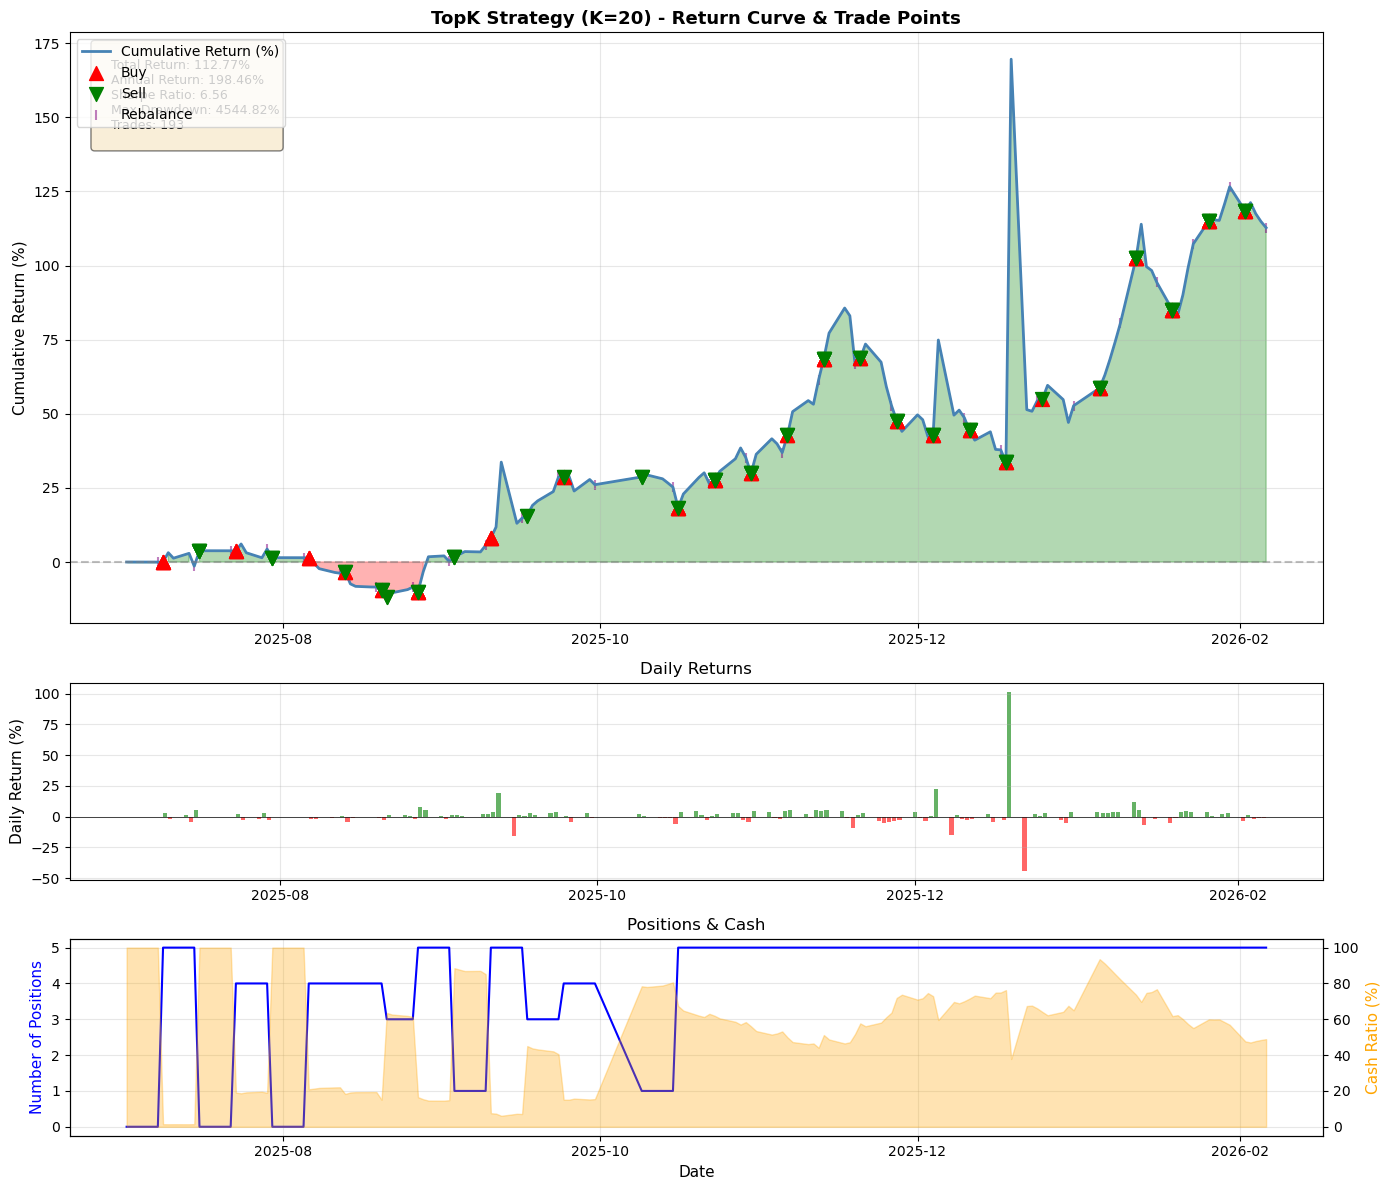

In [20]:
import importlib
import backtrader_topk_strategy
importlib.reload(backtrader_topk_strategy)

from backtrader_topk_strategy import run_topk_backtest_ultra_optimized, create_trade_chart

# 推荐使用超优化版本
result = run_topk_backtest_ultra_optimized(
  test_df=test_features,
  pred_col='pred_return',
  code_col='code',
  date_col='date',
  price_col='close',
  top_k=5,                # 每天选20只
  rebalance_freq=5,        # 每周再平衡
  equal_weight=True,       # 等权重
  min_data_days=150,         # 最小数据天数
  initial_cash=1000000,
  commission=0.00025
)

print(f"总收益率: {result['total_return']*100:.2f}%")
print(f"处理时间: {result.get('elapsed_time', 'N/A')}s")

# 显示图表
create_trade_chart(result, title="TopK Strategy (K=20)", save_path="./topk_result.png")

🚀 Threshold 策略回测（超优化版 - Vectorized GroupBy）

📊 使用 GroupBy 向量化处理...
✅ 数据处理完成 (5.59s):
   成功添加: 6066 只股票
   跳过: 313 只
   信号日期: 174 天

💰 开始回测...
2025-07-08   当前持仓: 0 只
2025-07-08   买入信号 600962: 预测0.0548, 仓位18.3%
2025-07-08   买入信号 605500: 预测0.0444, 仓位14.8%
2025-07-08   买入信号 003003: 预测0.0350, 仓位11.7%
2025-07-09 【买入】600962: 11233股 @ 17.88
2025-07-09 【买入】605500: 13500股 @ 12.07
2025-07-09 【买入】003003: 8352股 @ 13.52
2025-07-15   当前持仓: 3 只
2025-07-15   卖出信号 600962: 预测-0.0110
2025-07-15   卖出信号 605500: 预测-0.0248
2025-07-15   买入信号 688585: 预测0.2141, 仓位20.0%
2025-07-15   买入信号 159851: 预测0.0795, 仓位20.0%
2025-07-15   买入信号 002125: 预测0.0418, 仓位13.9%
2025-07-15   买入信号 301108: 预测0.0373, 仓位12.4%
2025-07-15   买入信号 603176: 预测0.0313, 仓位10.4%
2025-07-15   买入信号 301076: 预测0.0303, 仓位10.1%
2025-07-16 【卖出】600962: 11233股 @ 20.80
2025-07-16 【卖出】605500: 13500股 @ 13.44
2025-07-16 【买入】688585: 10445股 @ 23.24
2025-07-16 【买入】159851: 239154股 @ 0.84
2025-07-16 【买入】002125: 10635股 @ 13.27
2025-07-16 【买入】301108: 5403股 @ 23.47
2025

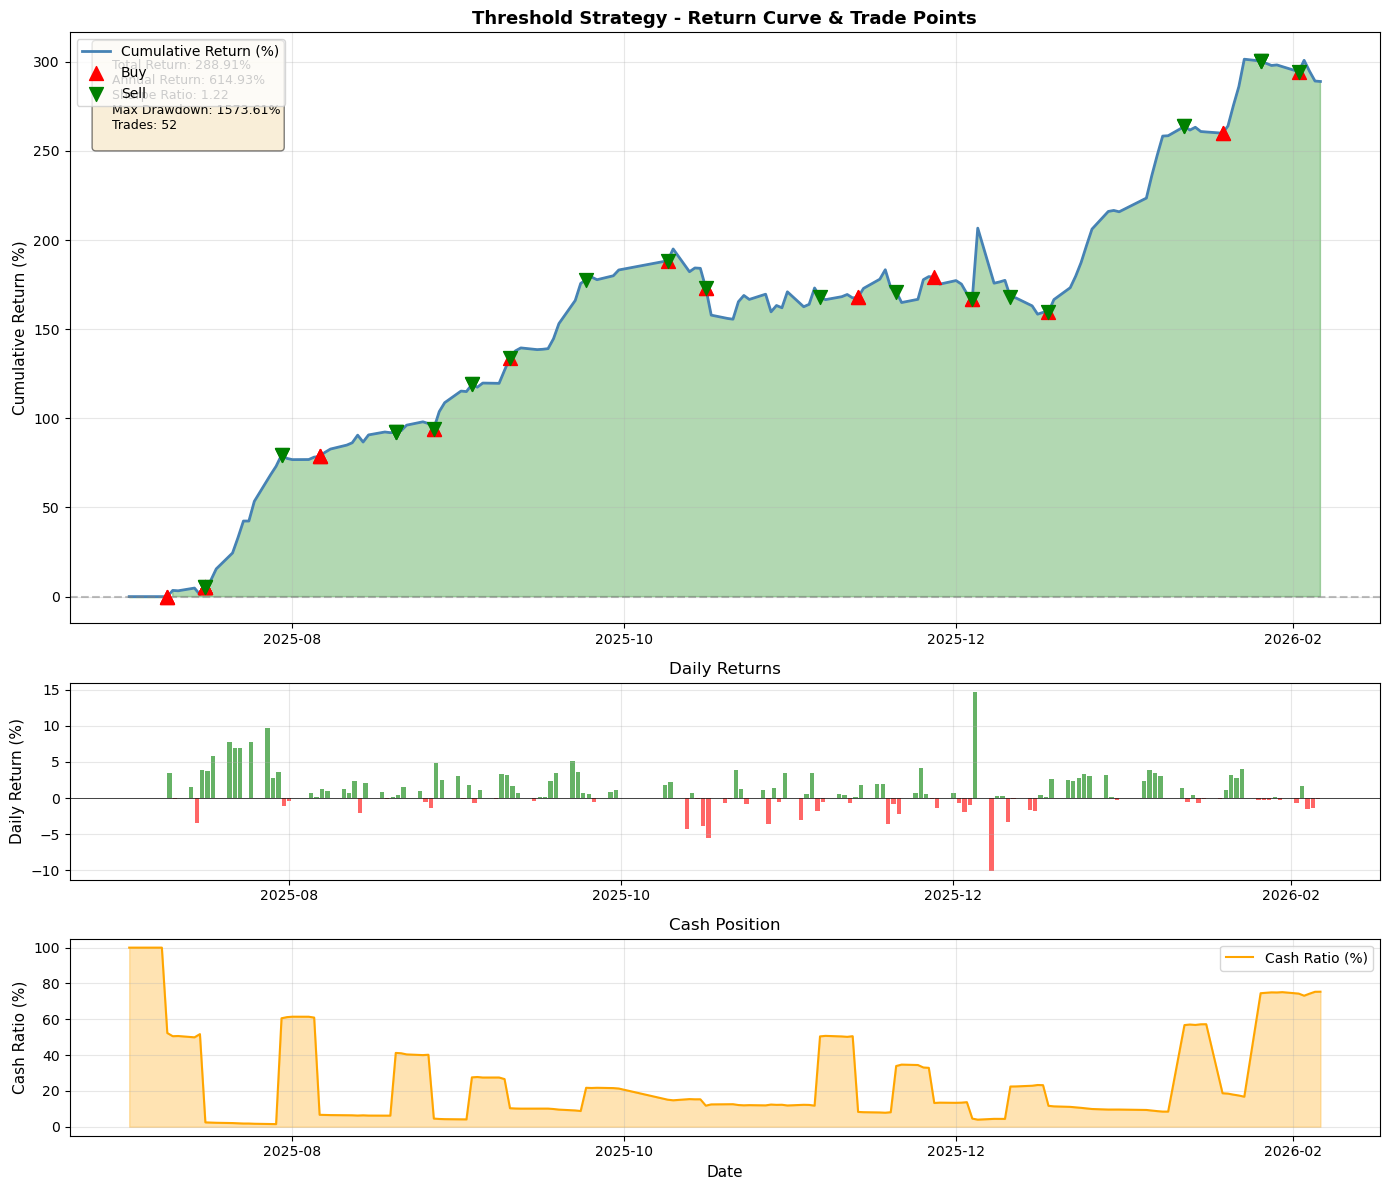


📊 交易盈亏分析

总交易次数: 25
盈利次数: 19 (76.0%)
亏损次数: 6 (24.0%)

总盈亏: 2,946,303.04
平均盈亏: 117,852.12
平均收益率: 30.74%

平均盈利: 163,753.28
最大盈利: 837,472.79
平均亏损: -27,501.55
最大亏损: -67,861.93

平均持仓天数: 34.4天

----------------------------------------------------------------------
📋 交易明细（按盈亏排序）
----------------------------------------------------------------------
排名   代码         买入日期         卖出日期         收益率        盈亏           持仓天数    
----------------------------------------------------------------------
1    001331     2025-12-18   2026-01-12    +146.76% +837472.79   25      
2    688585     2025-07-16   2025-07-30    +296.17% +718929.35   14      
3    605255     2025-08-27   2025-11-06    +137.77% +597301.25   71      
4    002931     2026-01-19   2026-01-26     +46.43% +368336.76   7       
5    159876     2025-08-06   2025-10-09     +42.20% +151819.32   64      
6    000407     2025-11-13   2025-11-20     +18.45% +108639.81   7       
7    589520     2025-09-10   2026-01-26     +19.32% +89034.62    

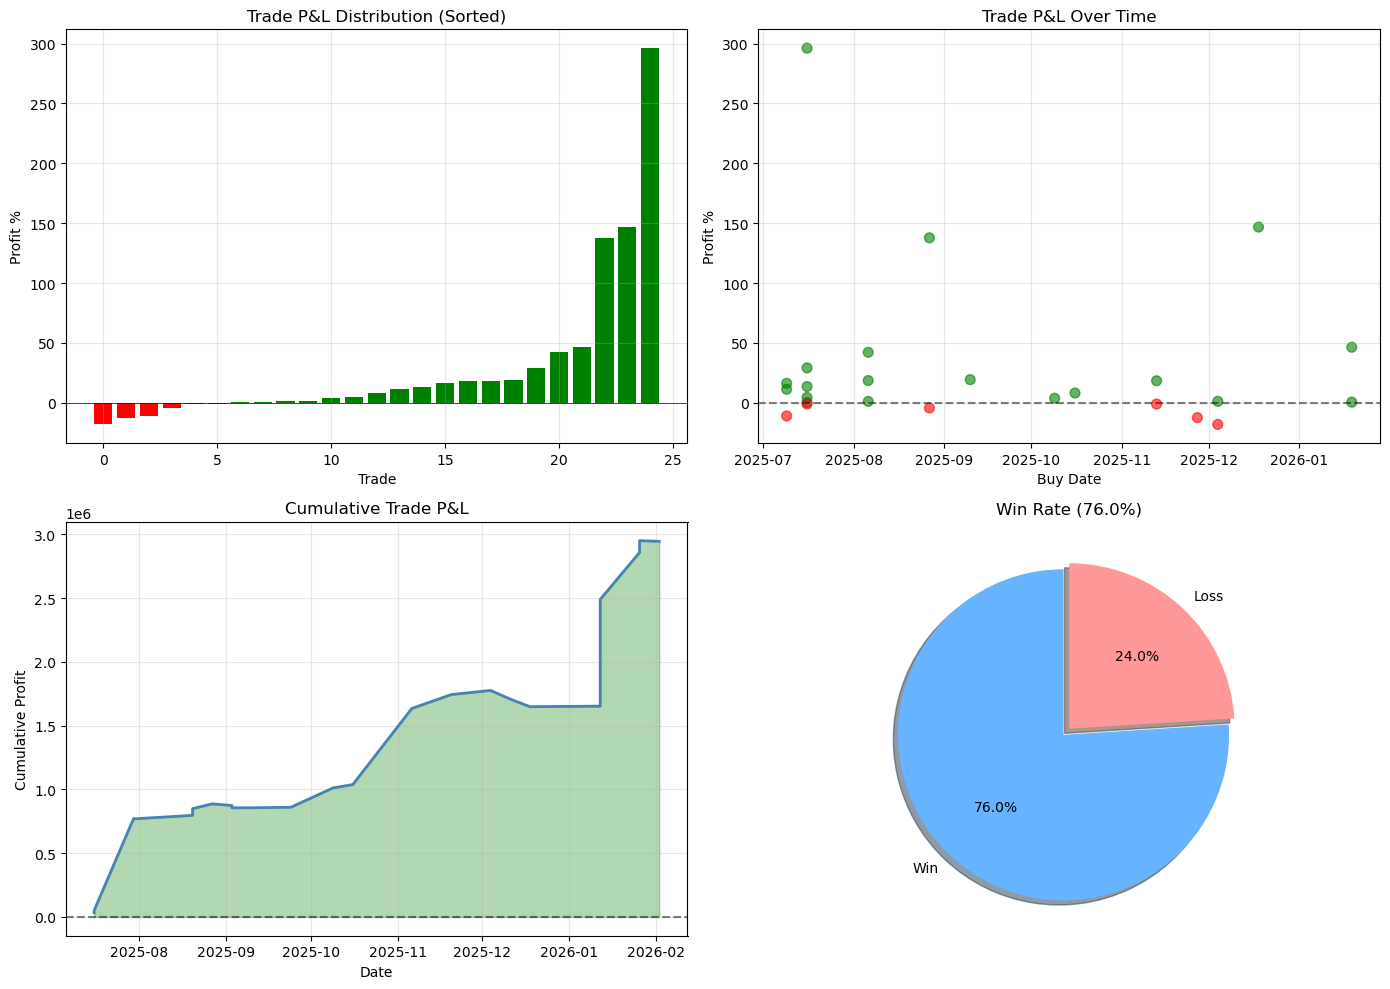

,code,buy_date,sell_date,buy_price,sell_price,size,profit,profit_pct,holding_days
0,600962,2025-07-09,2025-07-16,17.8800,20.800,11233,32800.360,16.331096,7
1,605500,2025-07-09,2025-07-16,12.0700,13.440,13500,18495.000,11.350456,7
2,003003,2025-07-09,2025-09-03,13.5200,12.040,8352,-12360.960,-10.946746,56
3,688585,2025-07-16,2025-07-30,23.2400,92.070,10445,718929.350,296.170396,14
4,159851,2025-07-16,2025-08-20,0.8450,0.960,239154,27502.710,13.609467,35
5,002125,2025-07-16,2025-08-20,13.2700,13.870,10635,6381.000,4.521477,35
6,301108,2025-07-16,2025-08-27,23.4700,30.320,5403,37010.550,29.186195,42
7,603176,2025-07-16,2025-09-10,6.3700,6.390,15570,311.400,0.313972,56
8,301076,2025-07-16,2025-07-30,30.6100,30.320,3274,-949.460,-0.947403,14
9,159876,2025-08-06,2025-10-09,0.6540,0.930,550070,151819.320,42.201835,64


In [26]:
import importlib
import backtrader_threshold_strategy
importlib.reload(backtrader_threshold_strategy)

from backtrader_threshold_strategy import run_threshold_backtest_ultra, create_trade_chart, analyze_trade_profit_loss

# 使用超优化版本
result = run_threshold_backtest_ultra(
  test_df=test_features,
  pred_col='pred_return',
  buy_threshold=0.03,
  sell_threshold=-0.01,
  max_positions=10,
  rebalance_freq=5,        # 每周再平衡
  min_data_days=150,         # 最小数据天数
  initial_cash=1000000,
  commission=0.00025,
  print_log=True
)

print(f"总耗时: {result['elapsed_time']:.2f}s")
print(f"总收益率: {result['total_return']*100:.2f}%")

# 绘制图表
create_trade_chart(result, title="Threshold Strategy", save_path="./result.png")
analyze_trade_profit_loss(result, save_path='./pnl_analysis.png')